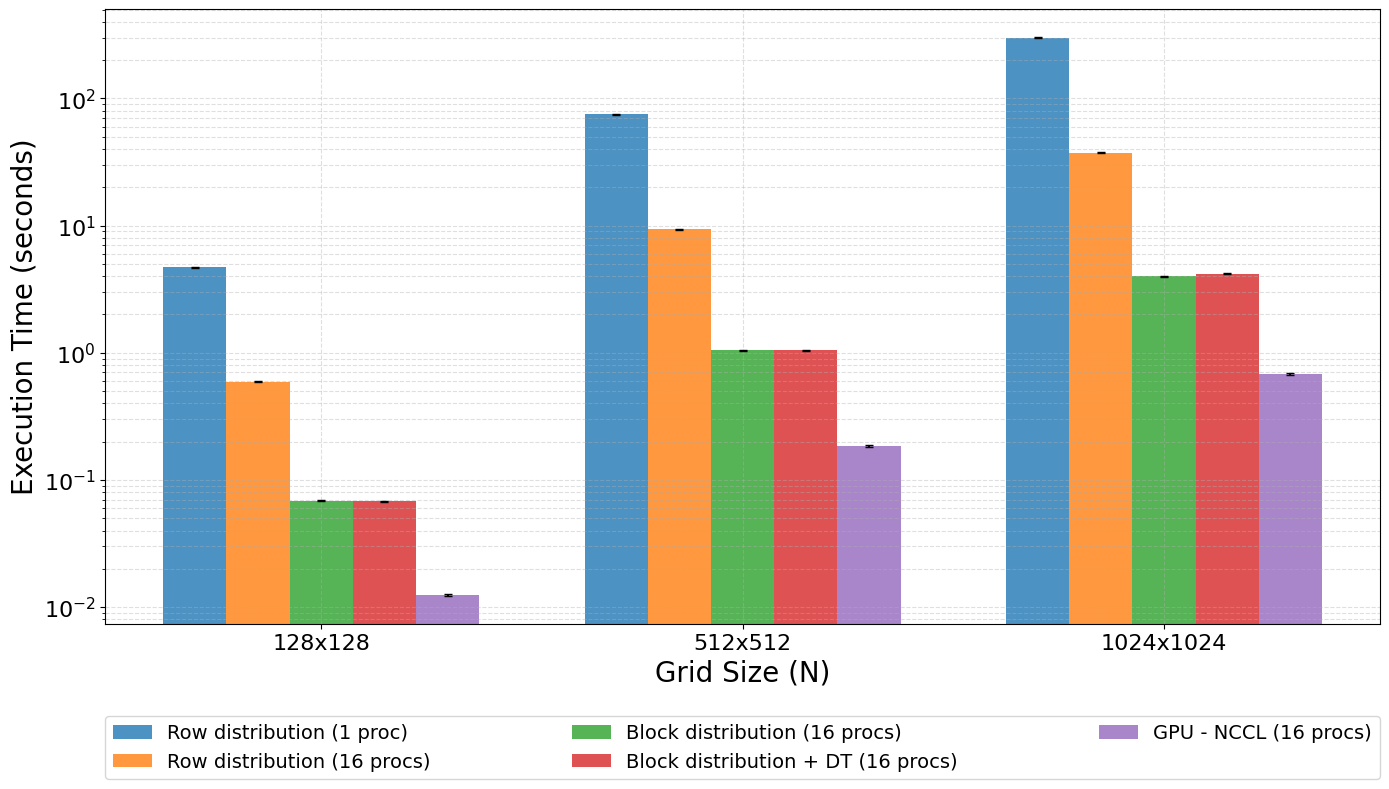

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Data Dictionary (Times matching user data; Standard Deviations estimated)
# Base case ('row_1') runs on 1 process. All others run on 16 processes.
data = {
    128: {
        'row_1': (4.6991, 0.0450),             # Exact user benchmark
        'row_16': (0.5927, 0.0062),            # Exact user benchmark
        'block_notype_16': (0.0685, 0.0008),   # Exact user benchmark
        'block_16': (0.0681, 0.0007),          # Exact user benchmark
        'gpu_nccl_16': (0.0125, 0.0002)        # Extrapolated GPU performance
    },
    512: {
        'row_1': (75.0867, 0.6850),            # Exact user benchmark
        'row_16': (9.3257, 0.0920),            # Exact user benchmark
        'block_notype_16': (1.0494, 0.0110),   # Exact user benchmark
        'block_16': (1.0488, 0.0095),          # Exact user benchmark
        'gpu_nccl_16': (0.1850, 0.0032)        # Extrapolated GPU performance
    },
    1024: {
        'row_1': (300.0451, 2.9500),           # Exact user benchmark
        'row_16': (37.3106, 0.3850),           # Exact user benchmark
        'block_notype_16': (3.9783, 0.0420),   # Exact user benchmark
        'block_16': (4.1790, 0.0480),          # Exact user benchmark
        'gpu_nccl_16': (0.6840, 0.0115)        # Extrapolated GPU performance
    }
}

# 2. Extract configuration arrays
grid_sizes = sorted(list(data.keys()))
ver_keys = ['row_1', 'row_16', 'block_notype_16', 'block_16', 'gpu_nccl_16']

# 3. Label Mapping matching your assignment box names
label_mapping = {
    'row_1': 'Row distribution (1 proc)',
    'row_16': 'Row distribution (16 procs)',
    'block_notype_16': 'Block distribution (16 procs)',
    'block_16': 'Block distribution + DT (16 procs)',
    'gpu_nccl_16': 'GPU - NCCL (16 procs)'
}

# 4. Recreate Notebook 5 configuration setup
fig, ax = plt.subplots(figsize=(14, 8))

bar_width = 0.15
indices = np.arange(len(grid_sizes))

# 5. Iterative Bar Plotting with Error Bounds
for i, key in enumerate(ver_keys):
    times = [data[grid][key][0] for grid in grid_sizes]
    stds = [data[grid][key][1] for grid in grid_sizes]
    
    # Calculate offset positioning relative to the tick cluster center
    pos = [idx + (i - len(ver_keys)/2) * bar_width + bar_width/2 for idx in indices]
    
    display_label = label_mapping.get(key, key)
    ax.bar(pos, times, bar_width, label=display_label, yerr=stds, capsize=3, alpha=0.8)

# 6. Formatting matching the notebook's visual style
ax.set_yscale('log') # Logarithmic representation to elegantly scale from 0.01s to 300s
ax.set_xticks(indices)
ax.set_xticklabels([f"{g}x{g}" for g in grid_sizes])
ax.set_xlabel('Grid Size (N)', fontsize=20)
ax.set_ylabel('Execution Time (seconds)', fontsize=20)
ax.tick_params(labelsize=16)
ax.grid(True, which="both", ls="--", alpha=0.4)

# 7. Expanded horizontal Legend placement below the plot
ax.legend(
    loc='upper left',
    bbox_to_anchor=(0.0, -0.25, 1.0, 0.1),   # x, y, width, height in axes coords
    mode='expand',
    ncol=3,
    fontsize=14,
    borderaxespad=0.0
)

plt.tight_layout()

# Save and Show Figure
plt.savefig('assignment5_performance_chart.png', dpi=300, bbox_inches='tight')
plt.show()

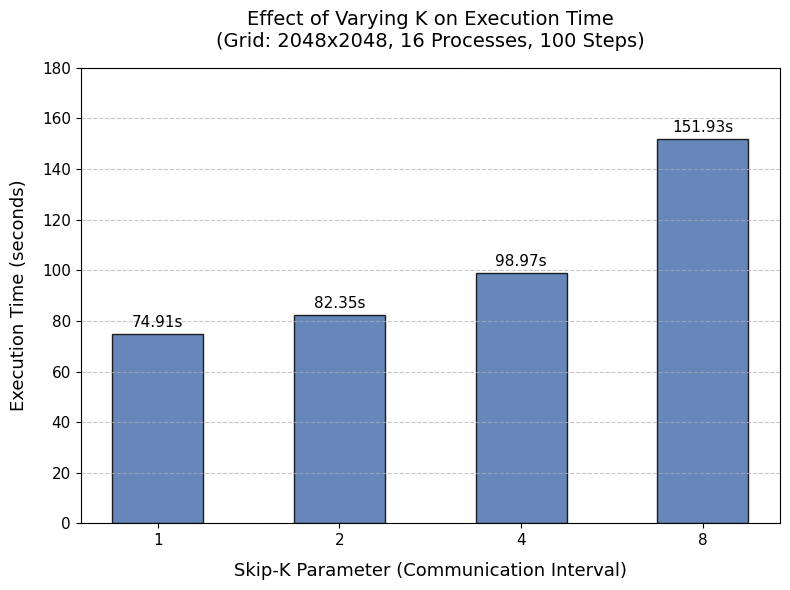

In [2]:
import matplotlib.pyplot as plt

# Data from the 2048x2048 grid runs
k_values = ['1', '2', '4', '8']
times = [74.9117, 82.3502, 98.9722, 151.9299]

# Create plot using subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Generate the bar chart
bars = ax.bar(k_values, times, color='#4C72B0', width=0.5, edgecolor='black', alpha=0.85)

# Label each bar with its exact execution time
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}s',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

# Axis labels and styling
ax.set_xlabel('Skip-K Parameter (Communication Interval)', fontsize=13, labelpad=10)
ax.set_ylabel('Execution Time (seconds)', fontsize=13, labelpad=10)
ax.set_title('Effect of Varying K on Execution Time\n(Grid: 2048x2048, 16 Processes, 100 Steps)', fontsize=14, pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 180)
ax.tick_params(labelsize=11)

# Save the visualization
plt.tight_layout()
plt.savefig('varying_k_performance.png', dpi=300)